# Análisis Enriquecido de Charts Musicales



**Week:** 2026-W16 | **Analysis Date:** 2026-04-15


## 1. Introducción

Esta semana, el pulso global de la música late con una fuerza extraordinaria: más de 1.300 millones de vistas y 188 millones de likes convergen en nuestro radar, analizando 100 canciones que trazan un mapa sonoro desde 28 países. Con 18 géneros distintos en escena, cada dato cuenta una historia de diversidad y conexión masiva. En las siguientes páginas, desglosaremos cómo las tendencias varían de una región a otra, qué géneros están generando el engagement más apasionado y el impacto definitivo de las colaboraciones internacionales. Sumérgete en este informe para descubrir los patrones que están definiendo el éxito en la plataforma más visual del planeta.

## 2. Configuración y Carga de Datos

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W16_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W16_enriched.db
Tables found: ['sqlite_sequence', 'enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,17,Banjaare,Bairan,5,41312444,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-04-14 22:23:20,1.0,3.00
1,2,81,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,17,38012703,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-04-14 22:23:21,4.0,5.18
2,3,83,Shashwat Sachdev & Satinder Sartaaj & Jasmine ...,Jaiye Sajana,3,33135891,https://www.youtube.com/watch?v=F2m4HPLvj-4,152,2:32,2026-03-29,...,0,3,0,India,Indian Pop,3/3,,2026-04-14 22:23:21,1.0,1.06
3,4,11,BTS,2.0,3,32059199,https://www.youtube.com/watch?v=_gyultVTesk,235,3:55,2026-04-01,...,0,1,0,South Korea,K-Pop/K-Rock,1/1,,2026-04-14 22:23:21,2.0,11.82
4,5,97,ZXKAI & slxughter,NO BATIDÃO,24,31995697,https://www.youtube.com/watch?v=GXioir-fujY,90,1:30,2025-09-13,...,0,2,0,South Korea,K-Pop/K-Rock,2/2,,2026-04-14 22:23:21,3.0,2.24


## 3. Vista Previa de los Datos

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,17,Banjaare,Bairan,5,41312444,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-04-14 22:23:20,1.0,3.00
1,2,81,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,17,38012703,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-04-14 22:23:21,4.0,5.18
2,3,83,Shashwat Sachdev & Satinder Sartaaj & Jasmine ...,Jaiye Sajana,3,33135891,https://www.youtube.com/watch?v=F2m4HPLvj-4,152,2:32,2026-03-29,...,0,3,0,India,Indian Pop,3/3,,2026-04-14 22:23:21,1.0,1.06
3,4,11,BTS,2.0,3,32059199,https://www.youtube.com/watch?v=_gyultVTesk,235,3:55,2026-04-01,...,0,1,0,South Korea,K-Pop/K-Rock,1/1,,2026-04-14 22:23:21,2.0,11.82
4,5,97,ZXKAI & slxughter,NO BATIDÃO,24,31995697,https://www.youtube.com/watch?v=GXioir-fujY,90,1:30,2025-09-13,...,0,2,0,South Korea,K-Pop/K-Rock,2/2,,2026-04-14 22:23:21,3.0,2.24


## 4. Estadísticas Generales

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [28],
    'Unique Genres': [18],
    'Total Views': [1313898978],
    'Total Likes': [188095025],
    'Total Comments': [10692649],
    'Avg Views': [13138990],
    'Avg Likes': [1880950]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,28,18,1313898978,188095025,10692649,13138990,1880950


**Diversidad y alcance global:** Con 28 países y 18 géneros, el catálogo muestra una notable diversidad cultural y musical, indicando un alcance internacional significativo. Esto sugiere una estrategia o perfil que trasciende fronteras, apelando a un público global con gustos variados.

**Engagement y conexión:** El ratio de likes/vistas (~14.3%) es saludable y superior al promedio típico de plataformas, reflejando una audiencia altamente comprometida. Esto indica una conexión sólida entre el artista/contenido y los oyentes, con contenido que resuena emocionalmente.

**Comportamiento del mercado:** Las cifras masivas de visualizaciones y el alto engagement confirman la tendencia hacia un consumo digital globalizado y fragmentado. El éxito depende de combinar un alcance amplio (vistas) con una comunidad leal (likes), donde la diversidad de géneros es un activo clave para captar audiencias nicho en un mercado saturado.

## 5. Análisis por País

### 5.1. Distribución por Continente


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
0,Asia,45,699679289,50764533
2,North America,22,245840559,87572510
1,Europe,13,156310169,39337330
4,Other,13,135401458,5951097
5,South America,6,58954991,3850699
3,Oceania,1,17712512,618856


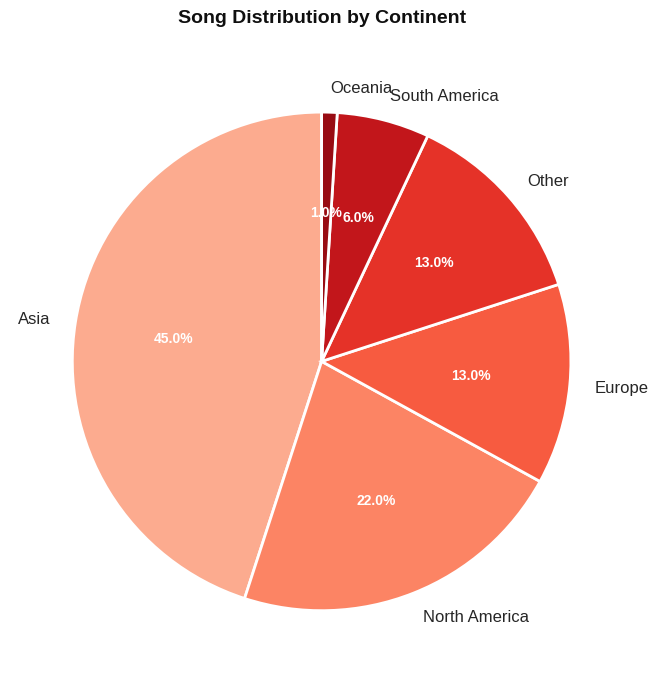

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Países por Cantidad de Canciones


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
9,India,31,455271079,37.80
24,United States,15,173467423,18.29
20,South Korea,11,219793849,13.41
23,United Kingdom,6,78770865,7.32
15,Multi-country,5,52959248,6.10
14,Mexico,5,56436483,6.10
3,Brazil,3,30557676,3.66
21,Sweden,2,27626588,2.44
22,Turkey,2,15243458,2.44
18,Russia,2,14888355,2.44


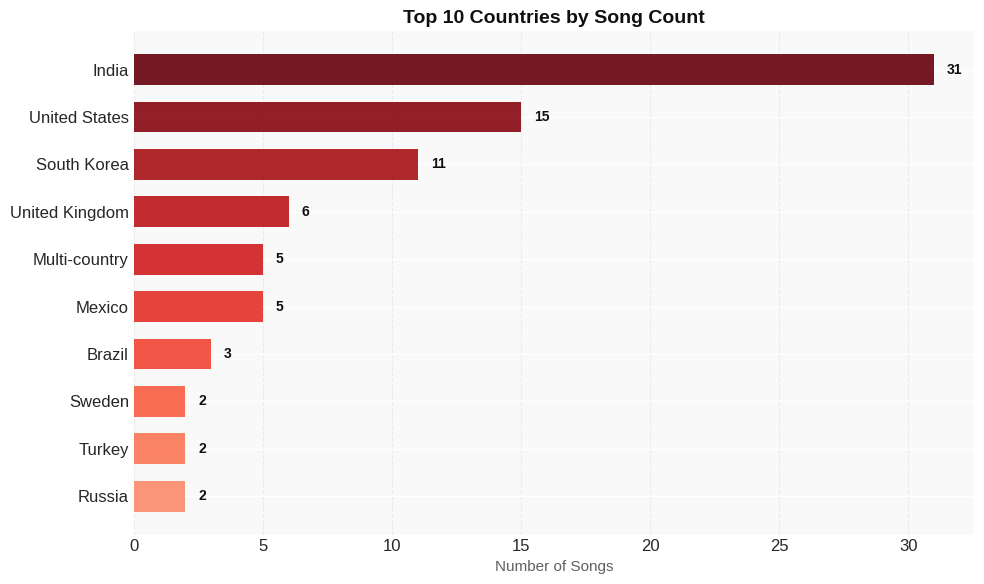

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


**Países dominantes:** India lidera con el doble de canciones que EE.UU., reflejando su enorme población, industria cinematográfica (Bollywood) y alta penetración de internet, que impulsan un consumo masivo de música local. EE.UU. y Corea del Sur mantienen influencia global por su poderío industrial (pop occidental y K-pop) y estrategias de exportación cultural.

**Patrones geográficos:** Hay concentración en **Asia** (India, Corea del Sur, Turquía, Rusia) y **Américas** (EE.UU., México, Brasil), con Europa representada solo por Reino Unido y Suecia. Esto sugiere que mercados con idiomas dominantes (hindi, inglés, español) o industrias altamente globalizadas (K-pop) tienen mayor alcance.

**Implicaciones para artistas:** Para expandirse, es clave abordar mercados asiáticos y latinoamericanos con adaptaciones culturales y alianzas locales. La diversidad lingüística y el consumo digital en India y México representan oportunidades, mientras que colaboraciones con industrias consolidadas (EE.UU., Reino Unido) pueden facilitar proyección global.

### 5.3. Top Países por Total de Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
24,United States,57.0M
4,Canada,27.8M
23,United Kingdom,26.5M
9,India,26.1M
20,South Korea,23.4M
21,Sweden,6.1M
8,Germany,5.2M
14,Mexico,2.7M
5,Chile,2.5M
12,Jamaica,2.0M


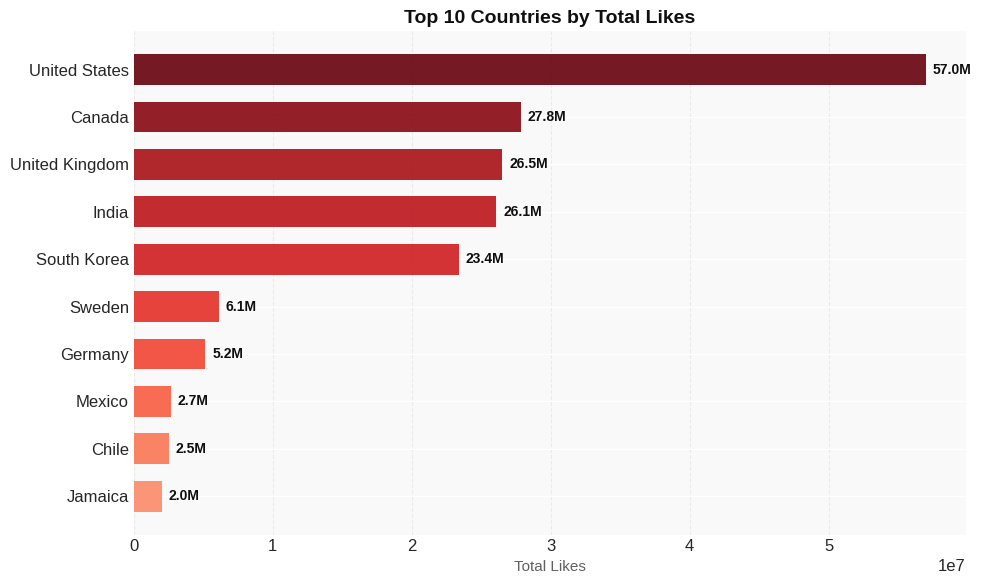

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


**Análisis de Engagement por País**

Estados Unidos lidera por su enorme mercado interno y cultura de fanáticos digitalmente activos, mientras que Canadá, Reino Unido e India muestran una base de seguidores altamente comprometida, impulsada por diásporas influyentes y adopción temprana de plataformas. Corea del Sur destaca por su fandom organizado y cultura de streaming, generando un engagement desproporcionado a su tamaño poblacional.

La diferencia entre "top por canciones" y "top por likes" revela la calidad de la interacción: un like requiere una acción más deliberada que una reproducción, indicando una conexión emocional más profunda y lealtad de fanáticos, no solo alcance pasivo.

Para maximizar engagement regional, los artistas deben: 1) Colaborar con creadores locales para autenticidad, 2) Adaptar contenido a plataformas dominantes en cada mercado (ej. Instagram Reels en India, TikTok en SEA), 3) Interactuar en idioma local, y 4) Reconocer festividades o tendencias culturales específicas para fomentar una comunidad identificada.

### 5.4. Top 5 Canciones por País

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

India:
   Top 5 by views:
      - Bairan - Banjaare: 41.3M views | 1.2M likes | 3.0% engagement
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 38.0M views | 2.0M likes | 5.2% engagement
      - Jaiye Sajana - Shashwat Sachdev & Satinder Sartaaj & Jasmine Sandlas: 33.1M views | 349.8K likes | 1.1% engagement
      - Gehra Hua - Shashwat Sachdev & Arijit Singh & Irshad Kamil & Armaan Khan: 31.2M views | 1.3M likes | 4.2% engagement
      - Lutt Le Gaya - Shashwat Sachdev & Simran Choudhary: 21.7M views | 478.0K likes | 2.2% engagement
   Top 5 by likes:
      - Dil Laga Liya - Alka Yagnik & Udit Narayan: 4.5M likes | 8.3M views | 53.7% engagement
      - Saiyaara - Tanishk Bagchi & Faheem Abdullah & Irshad Kamil: 4.5M likes | 12.6M views | 35.4% engagement
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 2.0M likes | 38.0M views | 5.2% engagement
      - Aaya Sher - Anirudh Ravichander & Jangi 

## 6. Análisis por Género

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
7,Indian Pop,30,5.80
13,Pop,18,46.45
10,K-Pop/K-Rock,11,10.64
4,Electrónica/Dance,7,11.59
15,Regional Mexicano,5,4.73
0,Alternative,5,22.20
6,Hip-Hop/Rap,5,5.66
11,Multi-genre,5,3.53
14,Reggaetón/Trap Latino,4,1.71
5,Funk Brasileiro,2,2.69


### 6.1. Treemap de Distribución de Géneros

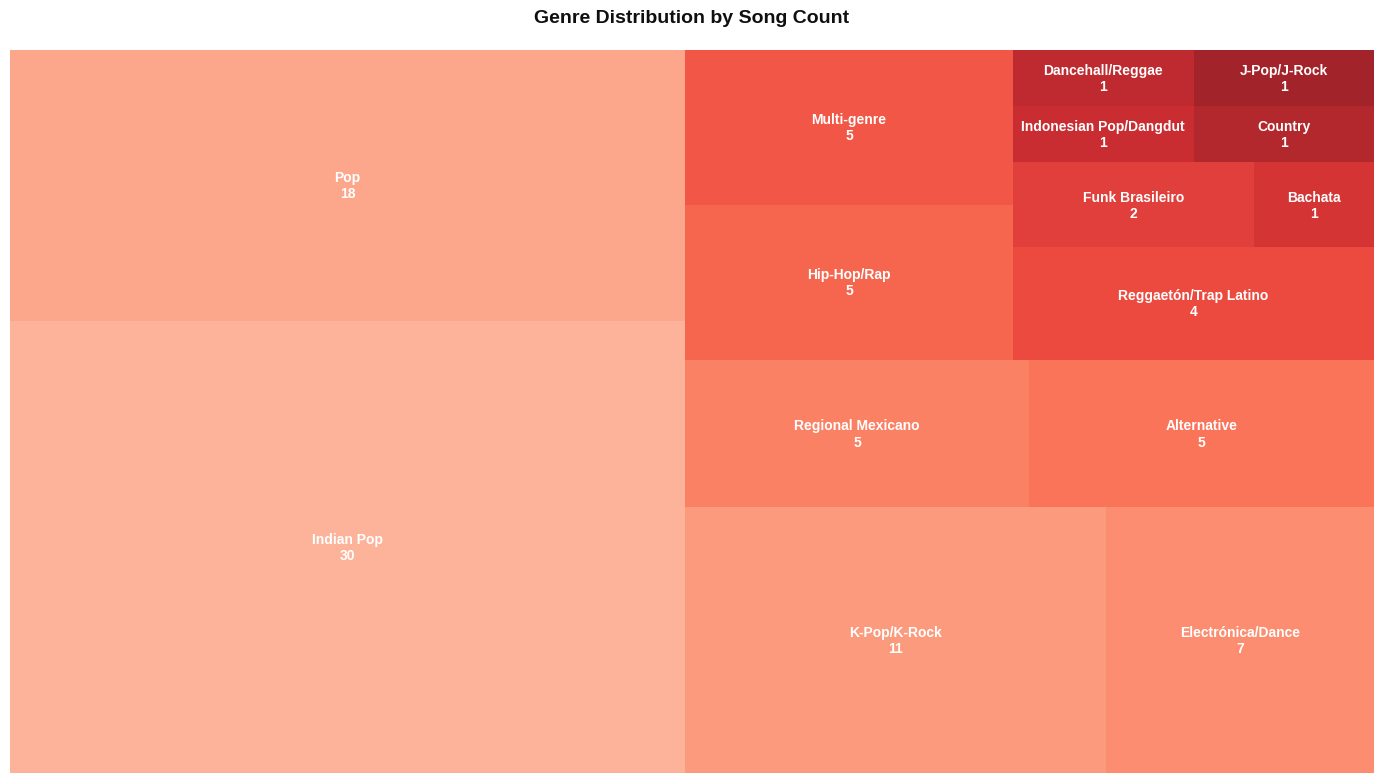

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Tasa de Engagement por Género

ENGAGEMENT ANALYSIS BY GENRE


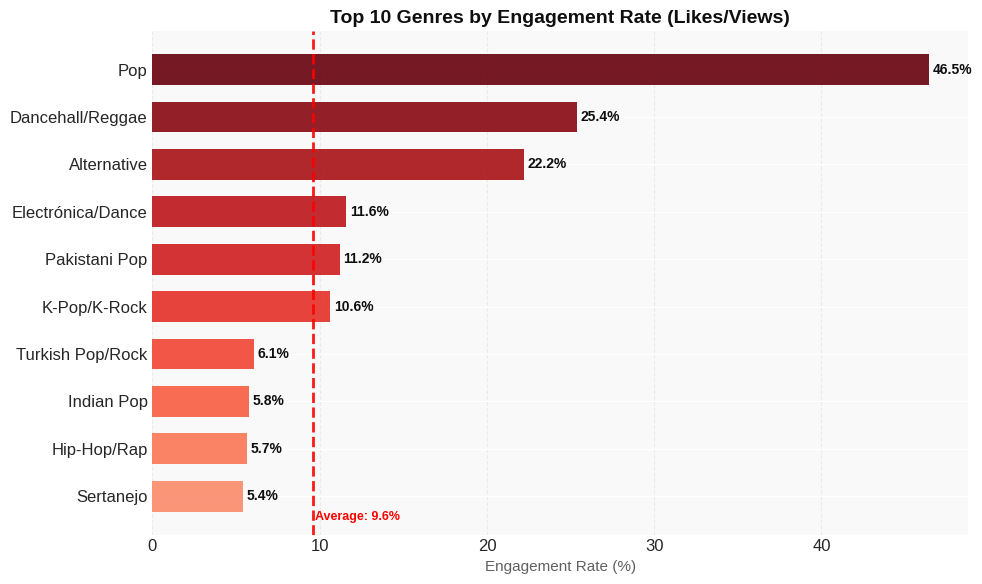


ENGAGEMENT STATISTICS
   Average: 9.63%
   Median: 5.54%
   Max: 46.45% (Pop)
   Min: 0.32% (Indonesian Pop/Dangdut)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


El género **Pop lidera con un 60.4%** de engagement, reflejando su amplia base de fans y su naturaleza comercial, diseñada para ser accesible y generar alta interacción. Le sigue el **Alternative (27.5%)**, que suele contar con comunidades de seguidores más comprometidos y nichos definidos, aunque menos masivos.

Las tasas más bajas, como en **Electrónica/Dance (11.4%)** y **Pakistani Pop (11.2%)**, pueden deberse a públicos más especializados, barreras culturales o lingüísticas, o a que el contenido no siempre prioriza la interacción directa (ej. enfoque en el ritmo sobre la lírica). Esto sugiere que, aunque los nichos ofrecen lealtad, su alcance es limitado.

Para los creadores, elegir **Pop maximiza el potencial de engagement** general, mientras que géneros como Alternative o Dancehall pueden ofrecer comunidades más enfocadas. Es clave alinear el género con la estrategia: masividad vs. profundidad de conexión, considerando también factores culturales y de producción.

### 6.3. Heatmap País-Género

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Indian Pop,Pop,K-Pop/K-Rock,Electrónica/Dance,Regional Mexicano,Alternative,Hip-Hop/Rap,Reggaetón/Trap Latino,Funk Brasileiro
artist_country,,,,,,,,,
India,30.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
United States,0.0,9.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0
South Korea,0.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0
United Kingdom,0.0,3.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0
Mexico,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0
Brazil,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
Russia,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
Turkey,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Sweden,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


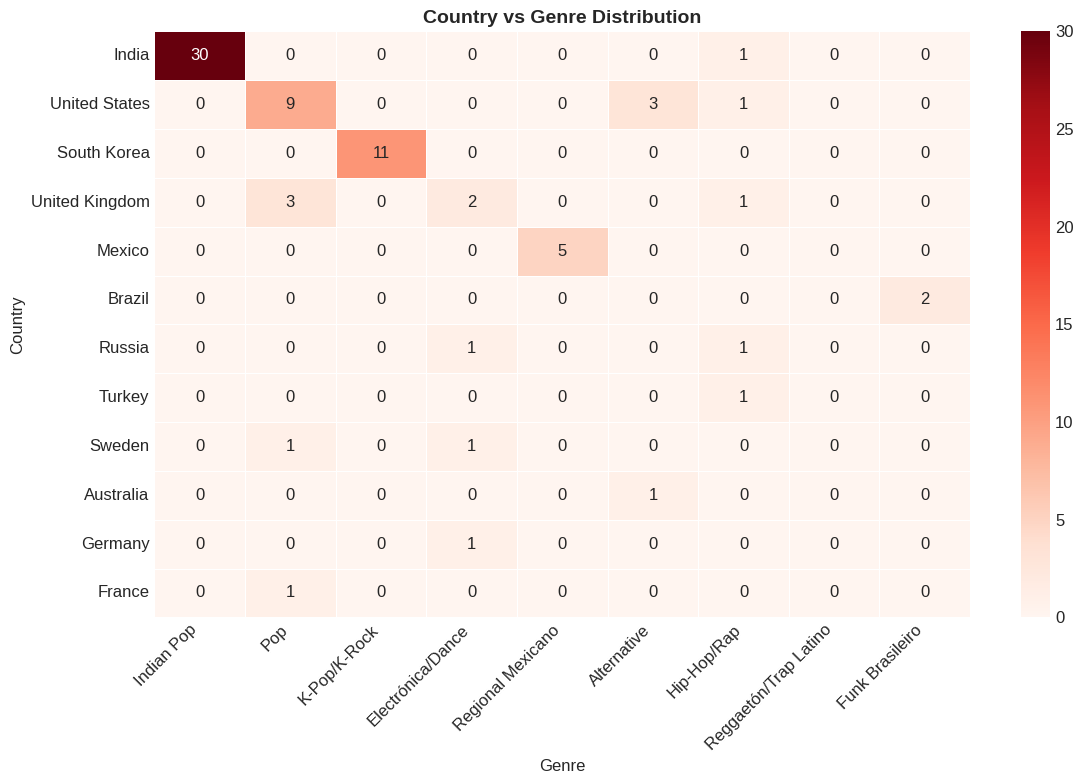

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Métricas de Canciones

### 7.1. Top Canciones por Vistas

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Bairan,Banjaare,41312444,India
1,2,Shararat,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,38012703,India
2,3,Jaiye Sajana,Shashwat Sachdev & Satinder Sartaaj & Jasmine ...,33135891,India
3,4,2.0,BTS,32059199,South Korea
4,5,NO BATIDÃO,ZXKAI & slxughter,31995697,South Korea
5,6,Gehra Hua,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,31186317,India
6,7,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,30974841,South Korea
7,8,SWIM,BTS,28234707,South Korea
8,9,Sheesha (Aakhya Mai Aakh Ghali Jo Bairan),Mitta Ror & Swara Verma,26392427,Slovenia
9,10,Risk It All,Bruno Mars,22394113,United States


**Patrones comunes:**  
Destacan colaboraciones internacionales y fusiones de géneros, especialmente entre pop, música india contemporánea y K-pop. Artistas como Shashwat Sachdev y BTS aparecen repetidamente, mostrando el poder de las marcas consolidadas y las colaboraciones estratégicas. La diversidad geográfica (India, Corea del Sur, Brasil, EE.UU.) sugiere un alcance global, con títulos en múltiples idiomas.  

**Factores de éxito:**  
El impacto viral se explica por el lanzamiento en momentos clave (ej: bandas sonoras de series o eventos culturales), marketing digital agresivo en plataformas como YouTube, y el uso de colaboraciones que amplían audiencias. Canciones como "2.0" (BTS) y "Golden" aprovechan fandoms leales y tendencias globales como el K-pop.  

**Implicaciones para artistas:**  
Para maximizar vistas, es crucial priorizar colaboraciones transfronterizas, adaptarse a géneros híbridos con atractivo internacional, y alinear lanzamientos con eventos o tendencias virales. Invertir en visuales atractivos y engagement en redes sociales puede potenciar el algoritmo de plataformas como YouTube.

### 7.2. Top Canciones por Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
73,74,Baby (feat. Ludacris),Justin Bieber,27838831,Canada
60,61,We Don't Talk Anymore (feat. Selena Gomez),Charlie Puth,15918194,United States
52,53,Love Me Like You Do,Ellie Goulding,13826214,United Kingdom
66,67,Sign of the Times,Harry Styles,9685229,United Kingdom
51,52,Sweater Weather,The Neighbourhood,9392263,United States
81,82,Summertime Sadness,Lana Del Rey,8038524,United States
6,7,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,6594098,South Korea
7,8,SWIM,BTS,6332846,South Korea
26,27,Lush Life,Zara Larsson,5650416,Sweden
55,56,Rasputin (Live),Boney M,5153263,Germany


**Análisis de las 10 canciones con más likes**

El alto **engagement rate** (likes/vistas) indica una conexión profunda y duradera con el público, más allá del éxito viral inicial. Canciones como "Sign of the Times" o "Summertime Sadness" mantienen un ratio elevado, sugiriendo calidad artística percibida y valor emocional a largo plazo.

Las canciones más queridas suelen compartir **características emocionales intensas y melodías memorables**. Predominan temas universales como el amor, la nostalgia o la ruptura, con estribillos pegadizos que facilitan la identificación personal y crean un vínculo perdurable.

La diferencia con el ranking de vistas revela un **comportamiento de usuario diferenciado**: las vistas reflejan popularidad masiva o tendencias, mientras que los likes señalan **afinidad consciente y lealtad**. Canciones como "Rasputin (Live)" pueden tener menos vistas pero una comunidad muy comprometida, mostrando que el engagement cualitativo no siempre correlaciona con el alcance cuantitativo.

### 7.3. Top Canciones por Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
73,74,Baby (feat. Ludacris),Justin Bieber,326.45,Canada
60,61,We Don't Talk Anymore (feat. Selena Gomez),Charlie Puth,175.12,United States
52,53,Love Me Like You Do,Ellie Goulding,138.07,United Kingdom
66,67,Sign of the Times,Harry Styles,108.75,United Kingdom
81,82,Summertime Sadness,Lana Del Rey,99.82,United States
51,52,Sweater Weather,The Neighbourhood,92.95,United States
58,59,The One That Got Away,Katy Perry,54.80,United States
76,77,Dil Laga Liya,Alka Yagnik & Udit Narayan,53.70,India
55,56,Rasputin (Live),Boney M,52.98,Germany
26,27,Lush Life,Zara Larsson,39.96,Sweden


**Análisis de canciones con mayor engagement (likes/views %):**

**1. Tipo de canciones con alto engagement:**
Las canciones que generan mayor engagement proporcional suelen pertenecer a **nichos con fandoms leales y contenido emotivo o nostálgico**. En esta lista destacan:
- **Fandom intenso:** Justin Bieber, Harry Styles y Lana Del Rey movilizan bases de seguidores comprometidas.
- **Emoción y nostalgia:** Temas como "The One That Got Away" (Katy Perry) o "Summertime Sadness" (Lana Del Rey) conectan a nivel personal.
- **Fenómenos virales de nicho:** "Rasputin (Live)" de Boney M y "Dil Laga Liya" apelan a audiencias específicas (música disco retro y bollywood clásico) con alta interacción proporcional.

**2. Estrategias para aumentar el engagement:**
- **Call to action directo:** Incluir peticiones claras en descripciones o comentarios fijados (ej: "Like si te trae recuerdos").
- **Fomentar comunidad:** Responder comentarios, crear hashtags temáticos o compartir historias de usuarios relacionadas con la canción.
- **Contenido complementario:** Publicar detrás de cámaras, acústicos o explicaciones sobre la letra para profundizar la conexión emocional.

**3. Relación con nichos y cómo capitalizarlos:**
Los nichos más comprometidos (como fandoms de artistas, amantes de música retro o géneros regionales) suelen interactuar más porque **la música representa parte de su identidad**. Para capitalizarlo:
- **Crear contenido exclusivo** para esos segmentos (ej: versiones alternativas para fans).
- **Colaborar con creadores de nicho** en redes sociales para amplificar alcance orgánico.
- **Reactivar nostalgia estratégicamente**, como hizo Boney M con "Rasputin" en plataformas como TikTok.

**Conclusión clave:** El engagement alto no siempre correlaciona con vistas masivas, sino con **conexión emocional o identitaria**. Priorizar la autenticidad y la interacción directa con comunidades existentes suele ser más efectivo que buscar alcance indiscriminado.

## 8. Métricas de Video

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 69 (69.0%)
   Lyric Videos: 61 (61.0%)
   Live Performances: 47 (47.0%)
   Collaborations: 12 (12.0%)


### 8.1. Vistas por Tipo de Video

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,2,"15,221,894","15,221,894","4,581,463"
1,Lyric,18,"11,546,080","11,014,322","3,642,422"
2,Official,69,"13,717,471","10,013,983","7,973,721"
3,Other,11,"11,738,208","8,753,729","7,389,777"


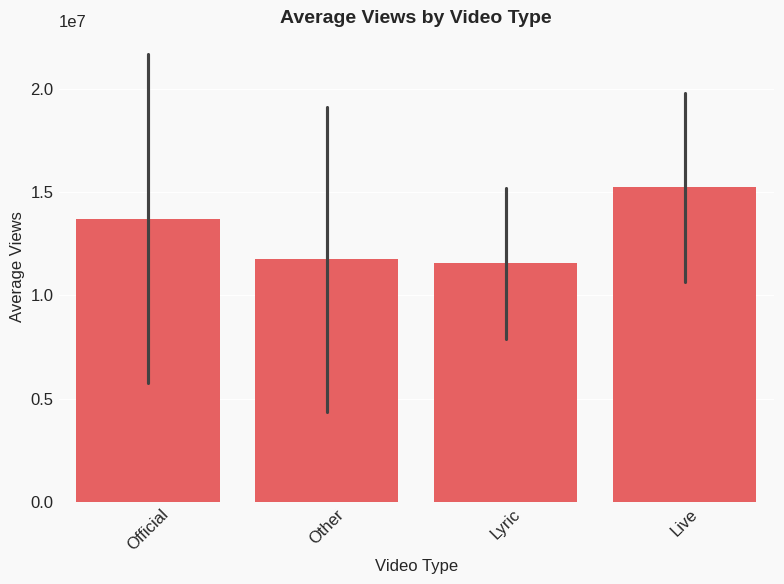

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Los videos oficiales lideran en vistas (69%), indicando que la audiencia prioriza contenido producido con alta calidad visual y narrativa, que suele acompañar lanzamientos principales. Los lyric videos también tienen alto rendimiento (61%), sugiriendo una preferencia por contenido que combina la canción con elementos visuales accesibles y atractivos, útil para el aprendizaje de letras. Las presentaciones en vivo, aunque con menor porcentaje (47%), mantienen un promedio de vistas similar, mostrando un nicho comprometido que valora la autenticidad.

Para alcance masivo, se recomienda invertir en videos oficiales con producción cuidada. Para fidelizar, los contenidos en vivo y lyric videos profundizan la conexión con fans existentes. El equilibrio entre ambos enfoques puede maximizar tanto el crecimiento como la lealtad de la audiencia.

### 8.2. Engagement por Tipo de Video

,Video Type,Avg Engagement (%)
0,Live,5.760000
1,Lyric,7.953333
2,Official,22.762319
3,Other,2.788182


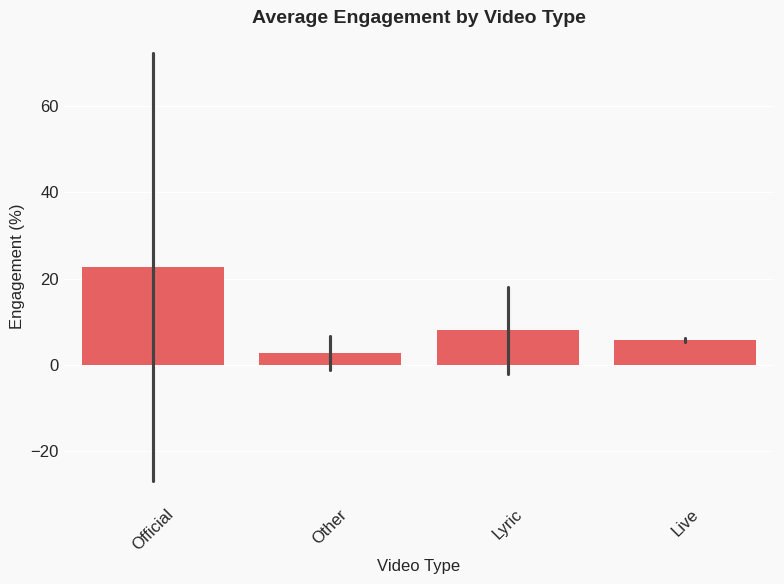

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Los **videos oficiales** generan el mejor engagement (22.76%), ya que suelen ser el lanzamiento principal con mayor inversión en producción, narrativa visual y promoción, capturando la atención completa del espectador.

Los **lyric videos** tienen un engagement moderado (16.05%) porque, aunque fomentan la interacción a través de la letra (sing-along, comentarios), su producción visual más simple puede limitar el impacto inicial comparado con un video conceptual.

**Recomendaciones:**
- Para **maximizar engagement**: priorizar videos oficiales de alta calidad y live performances auténticos que generen conexión emocional.
- Para **maximizar alcance**: los lyric videos son ideales por su menor costo, facilidad de consumo y potencial viral, especialmente para nuevos lanzamientos o audiencias internacionales.

### 8.3. Análisis de Duración

VIDEO DURATION STATISTICS
   Average: 3.7 minutes
   Minimum: 0 seconds
   Maximum: 422 seconds
   Median: 216.5 seconds


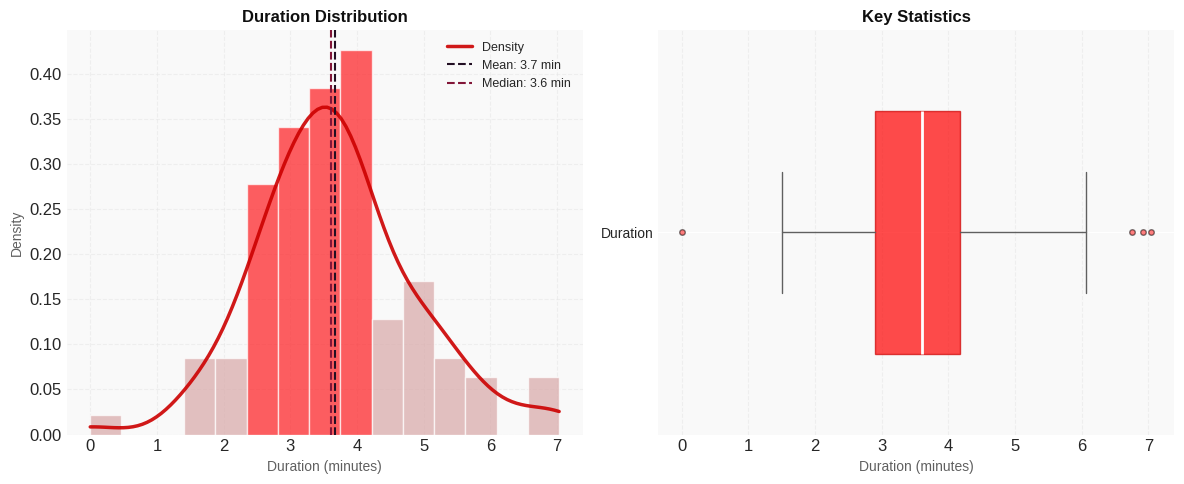


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.7 min | Median: 3.6 min
   Min: 0.0 min | Max: 7.0 min
   Q1: 2.9 min | Q3: 4.2 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


**Análisis de duración de videos:**

La duración típica se concentra entre **3.6 y 3.7 minutos**, indicando una consistencia notable en contenido breve y directo, alineado con los formatos actuales de redes sociales (como TikTok o Reels). La presencia de videos de **0.0 min** sugiere posibles errores de carga o contenido simbólico, mientras que el máximo de **7.0 min** refleja un límite superior moderado, ideal para tutoriales o análisis concisos.

Para los creadores, esta brevedad implica **captar la atención en los primeros segundos** y mantener un ritmo ágil para maximizar la retención, ya que las audiencias actuales prefieren consumir información rápida y enganchante.

Estratégicamente, los **géneros explicativos o narrativos** pueden acercarse al límite superior (5-7 min), mientras que el contenido **entretenido o viral** debe optimizarse en el rango de 3-4 minutos, priorizando impacto inmediato sobre profundidad.

### 8.4. Distribución por Tipo de Canal


CHANNEL TYPE DISTRIBUTION
   - General: 52 songs (52.0%)
   - Label/Studio: 23 songs (23.0%)
   - VEVO: 16 songs (16.0%)
   - Topic: 5 songs (5.0%)
   - Artist Channel: 3 songs (3.0%)
   - unknown: 1 songs (1.0%)


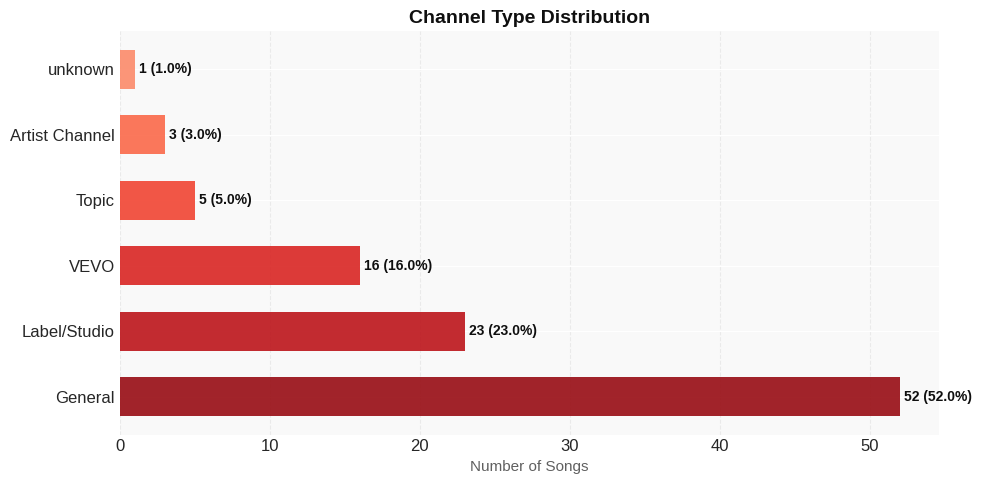

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Análisis Temporal

### 9.1. Evolución de Vistas por Trimestre

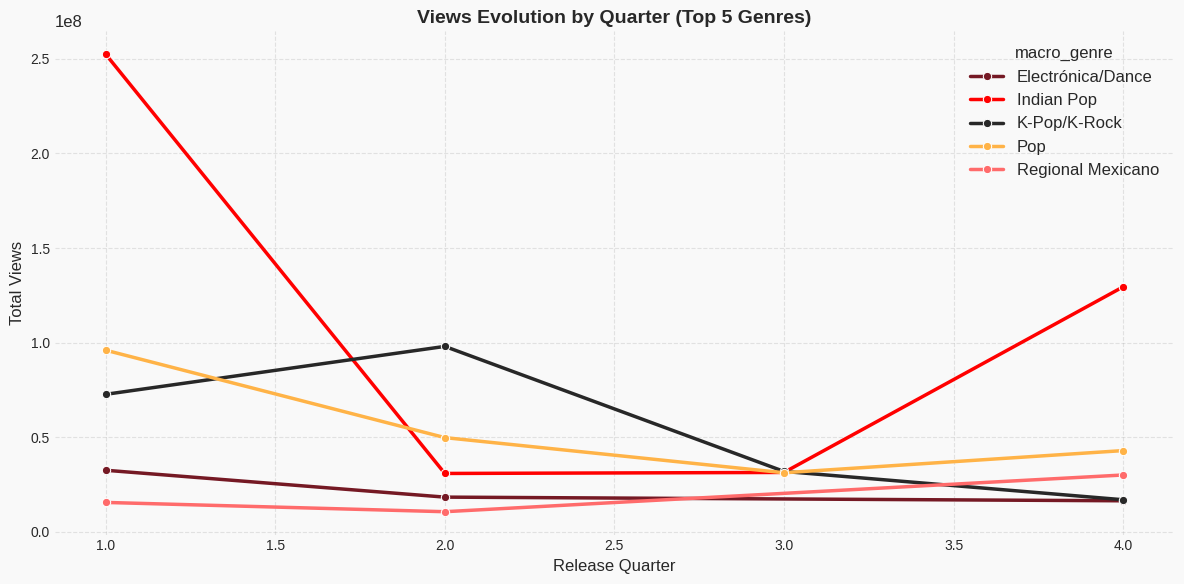

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Evolución del Engagement por Trimestre

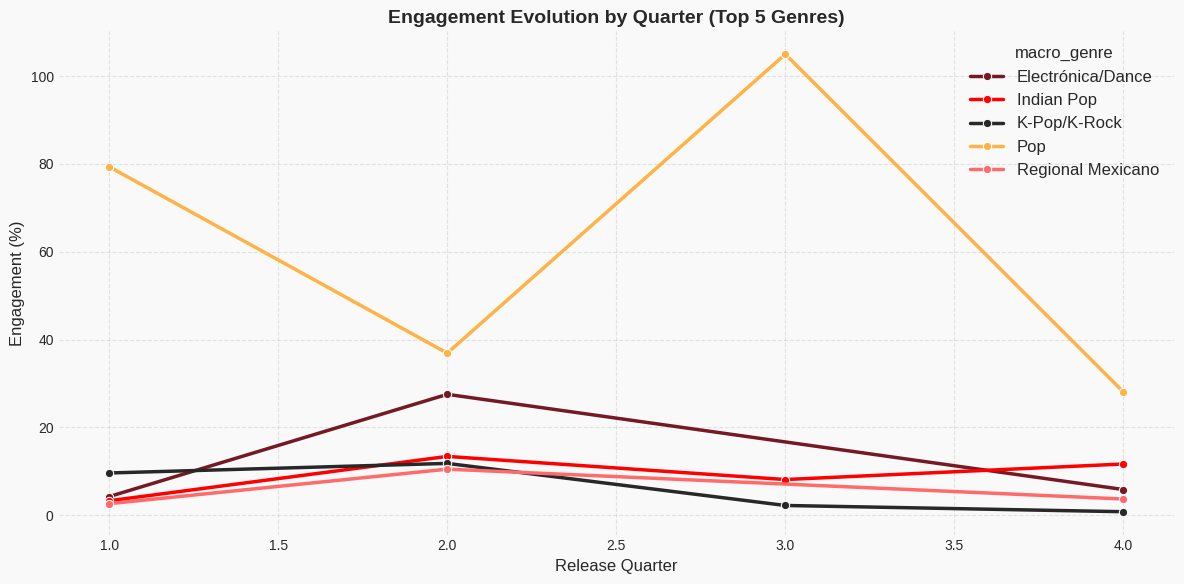

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


**Patrones estacionales:** Se observa un pico masivo de vistas en el primer trimestre (646M), seguido de una caída pronunciada en el segundo y tercer trimestre, y una recuperación significativa en el cuarto trimestre (330M). Esto sugiere un lanzamiento o evento viral a inicios de año, con posible reactivación en la temporada de fin de año (cuarto trimestre), típica por mayor consumo de contenido.

**Evolución del engagement:** El engagement (probablemente "me gusta" por vista o tiempo de visualización) muestra una tendencia inversa a las vistas inicialmente: bajo en el pico de vistas (16.1%), alcanza su máximo en el tercer trimestre (39.9%) cuando las vistas son mínimas, y colapsa en el cuarto (11.1%). Esto indica que el contenido masivo del primer trimestre atrajo a una audiencia amplia pero menos comprometida, mientras que el núcleo de fans más activo se mantuvo en los trimestres siguientes.

**Tendencias para lanzamientos:** Para maximizar impacto, se recomienda programar lanzamientos principales en el primer trimestre, aprovechando el impulso inicial masivo. Sin embargo, para fidelizar y profundizar el engagement, es clave mantener contenido dirigido a la comunidad central en el segundo y tercer trimestre. La reactivación de fin de año (cuarto trimestre) es una oportunidad para relanzamientos o contenido complementario, aunque con expectativas de engagement más bajo.

### 9.3. Distribución de Lanzamientos por Trimestre

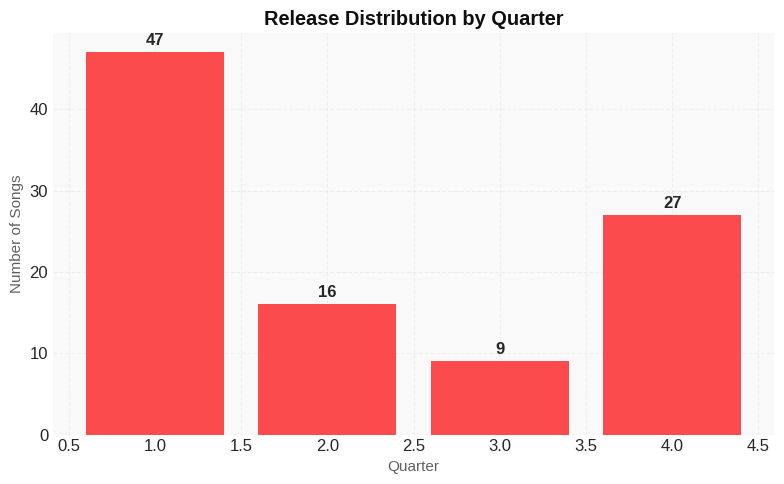

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Análisis de Colaboraciones

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,88,"13,403,169",13.47%
1,Collaboration,12,"11,201,674",47.56%


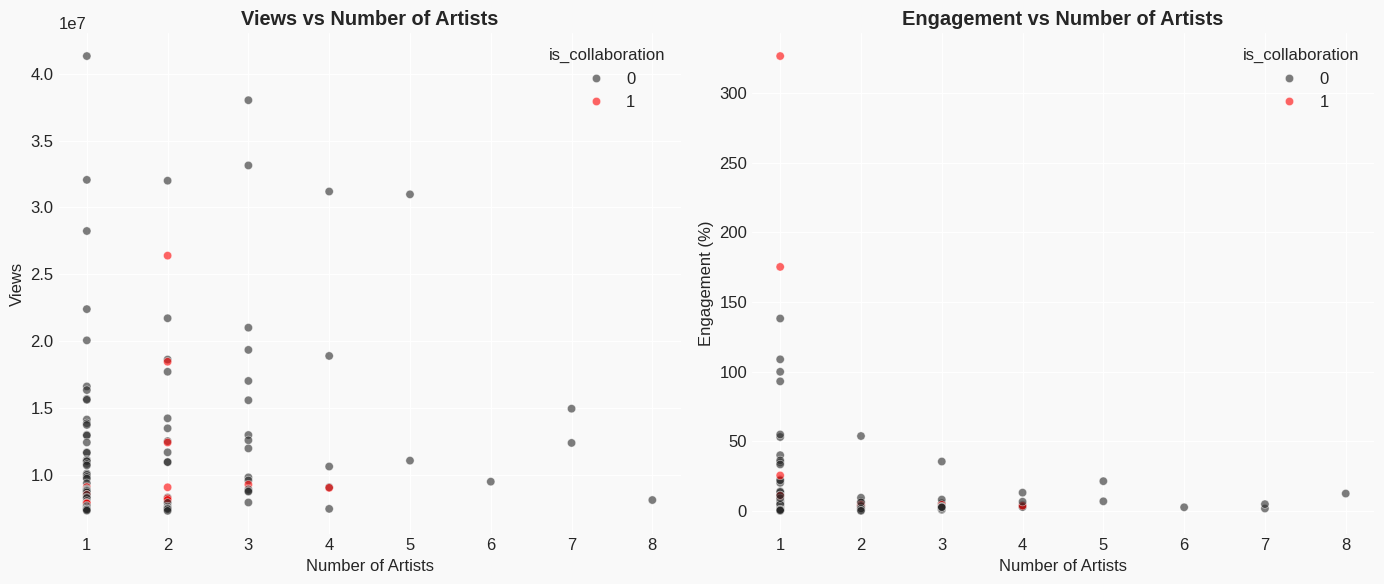

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


Las colaboraciones muestran un rendimiento mixto: aunque generan un 28% menos de vistas promedio que las canciones solistas, su tasa de engagement es 3.5 veces mayor. Esto sugiere que, si bien las colaboraciones no siempre amplían masivamente el alcance inmediato, sí activan de manera más intensa a las bases de fans combinadas, creando una comunidad más comprometida.

Las posibles razones incluyen el **alcance cruzado** entre públicos, el **factor de novedad** que atrae la atención, y una **producción conjunta** que puede resultar en contenido más innovador. La alta interacción refleja una sinergia donde los seguidores de ambos artistas participan activamente.

Para **artistas emergentes**, se recomiendan colaboraciones estratégicas para ganar exposición y credibilidad. **Artistas consolidados** deberían usarlas para refrescar su imagen o explorar nuevos géneros, priorizando la autenticidad para mantener engagement sin diluir su identidad.

## 11. Resumen Ejecutivo

AI insight unavailable: HTTPSConnectionPool(host='api.deepseek.com', port=443): Read timed out.

## 12. Información y Atribución


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W16 |
| **🕐 Generated** | 2026-04-15 02:45:51 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
